# GO proposal: Hybrid pulsators

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Paths to where data is stored
wdir = 'go_hybrid_pulsators'
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir(wdir)
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'sims'
fdir = path / 'figures'

In [4]:
df = pd.read_csv(ddir / 'check_nik_ids1.csv')#.sort_values(by='Gmag', ascending=False)
df.head()

,GaiaDR3,RA,DEC,Gmag,BP_RP
0,5546086321528617216,121.48046,-33.658387,16.433596,0.925021
1,5546086321528617216,121.48046,-33.658387,16.433596,0.925021
2,5546086321528617216,121.48046,-33.658387,16.433596,0.925021
3,5546086321528617216,121.48046,-33.658387,16.433596,0.925021
4,5322570867623851136,126.29889,-50.953505,14.507050,1.059119


<IPython.core.display.Javascript object>


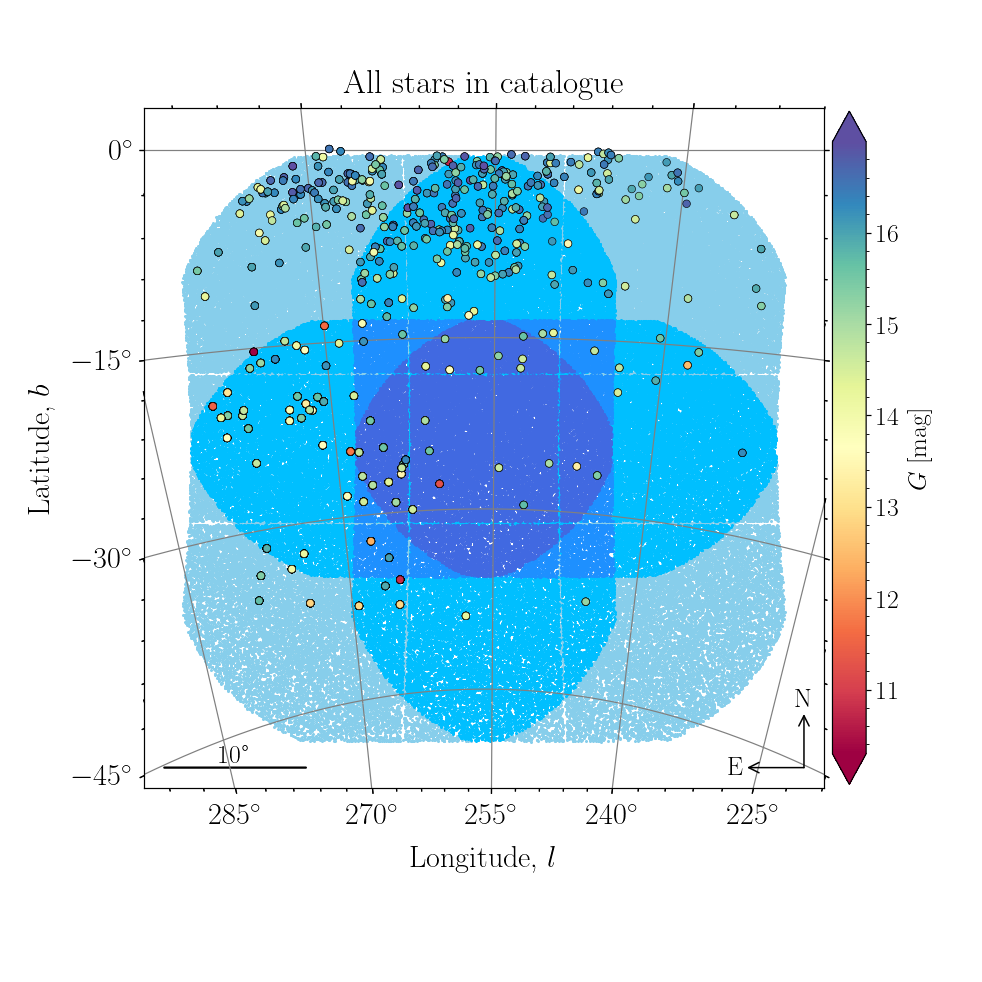

In [10]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df.RA, decStars=df.DEC, c=df.Gmag,
    clabel=r'$G$ [mag]', s=100, lw=0.4,
    title='All stars in catalogue', 
    figsize=(9,9),
)
# fig.savefig(fdir / f'aitoff_sample_all.png', bbox_inches='tight', dpi=200)

## Compute the SPR

#### Prepare simulations

In [11]:
# Rename column in order to match catalogues
dt = df.copy()
dt = dt.rename(columns={'GaiaDR3':'gaiaDR3', 'RA':'ra', 'DEC':'dec'})
dt['gaiaDR3'] = [f'Gaia DR3 {i}' for i in dt.gaiaDR3]
dt.head()

,gaiaDR3,ra,dec,Gmag,BP_RP
0,Gaia DR3 5546086321528617216,121.48046,-33.658387,16.433596,0.925021
1,Gaia DR3 5546086321528617216,121.48046,-33.658387,16.433596,0.925021
2,Gaia DR3 5546086321528617216,121.48046,-33.658387,16.433596,0.925021
3,Gaia DR3 5546086321528617216,121.48046,-33.658387,16.433596,0.925021
4,Gaia DR3 5322570867623851136,126.29889,-50.953505,14.507050,1.059119


In [12]:
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_hybrid_targets.ftr')

In [13]:
# Load PIC LOSP2 catalogue
dc = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')
dc.head()

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag
0,3110756000112,Gaia DR3 5212190448627272832,95.193683,-77.886883,15.213778,14.926610,15.235669,14.596222
1,3110756000113,Gaia DR3 5212190616130246656,95.141286,-77.886858,18.240141,17.982211,18.237360,17.696458
2,3110755000134,Gaia DR3 5212191960455806208,94.689049,-77.885060,18.910688,18.488089,19.384377,17.854926
3,3110757000131,Gaia DR3 5212236623819501824,95.869891,-77.885061,17.671410,17.447247,17.651479,17.208032
4,3110757000132,Gaia DR3 5212236417661073152,95.765300,-77.884838,18.137350,17.830000,18.183424,17.466040


In [15]:
# Create contaminant catalogue
dc = ut.getContaminants(dt, dc, column='gaiaDR3')
dc.to_feather(idir / f'starcat_hybrid_contaminants.ftr')

100%|██████████████████████████████████████████████████| 432/432 [01:27<00:00,  4.91it/s]                                                                            


#### Run simulations

In [14]:
# Create an parameterisation file
N = dt.shape[0]
from platosim.slurm import getParamFile
getParamFile(range(1,N+1), range(1,5), range(1,2), range(1,2), ofile=idir / 'cluster.data');

In [15]:
# Run simulation for only 1 exposure across all cameras
from platosim.hpc import HPC
hpc = HPC(wdir, cpus=6)
hpc.run(script='platonium', param_file='cluster.data', odir=sdir, kwargs='--nexp 1 -w -v 0')

 96%|████████████████████████████████████████████████  | 8952/9320 [1:42:19<04:32,  1.35it/s]                                                                        

Traceback (most recent call last):
  File "/lhome/nicholas/software/PlatoSim3/python/platosim/platonium/platonium.py", line 2339, in <module>
    p.run_sim_normal(sim)
  File "/lhome/nicholas/software/PlatoSim3/python/platosim/platonium/platonium.py", line 1356, in run_sim_normal
    simFile = sim.run(removeOutputFile=self.overwrite, logLevel=self.verbose_platosim)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/lhome/nicholas/software/PlatoSim3/python/platosim/simulation.py", line 508, in run
    raise Exception("Simulation.run(): PlatoSim returned with " +
Exception: Simulation.run(): PlatoSim returned with exit code -11.
100%|██████████████████████████████████████████████████| 9320/9320 [1:46:40<00:00,  1.46it/s]                                                                        


#### Add simulation information to main catalogue

In [16]:
# Fetch extra parameters from simulation tables
ncon = np.zeros(N) 
SPR = np.zeros(N)
NSR = np.zeros(N)
for i in range(1, N+1):
    star = f'{i}'.zfill(9)
    lcs = LightCurve(sdir/star, mode='multi')
    # Create table with simulation statistics
    if lcs.files() is not None:
        dt_sims = lcs.stat_sim_table(ofile=sdir/f'table_{star}.ftr', clean=False, verbose=False)
        ncon[i-1] = dt_sims.ncon.iloc[0]
        SPR[i-1]  = dt_sims.SPR.mean()
        NSR[i-1]  = dt_sims.NSR.mean()
    else:
        ncon[i-1] = None
        SPR[i-1]  = None
        NSR[i-1]  = None

[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000054
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000055
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000056
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000057
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000507
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000508
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000509
[Warning]: No files found with suffix hdf5! Check path: /lhome/nicholas/software/workdir/go_hybrid_pulsators/sims/000000510
[Warning

In [17]:
# Columns from simulations
dt0 = dt.copy()
dt0['ncon'] = ncon
dt0['SPR']  = SPR
dt0['NSR']  = NSR
dt0

,gaiaDR3,ra,dec,Gmag,BP_RP,ncon,SPR,NSR
0,Gaia DR3 5546086321528617216,121.480460,-33.658387,16.433596,0.925021,27.0,0.191284,0.213879
1,Gaia DR3 5546086321528617216,121.480460,-33.658387,16.433596,0.925021,27.0,0.191284,0.213879
2,Gaia DR3 5546086321528617216,121.480460,-33.658387,16.433596,0.925021,27.0,0.191284,0.213879
3,Gaia DR3 5546086321528617216,121.480460,-33.658387,16.433596,0.925021,27.0,0.191284,0.213879
4,Gaia DR3 5322570867623851136,126.298890,-50.953505,14.507050,1.059119,16.0,0.024762,0.039145
...,...,...,...,...,...,...,...,...
2325,Gaia DR3 4759917537519770752,84.669476,-58.961526,12.355151,0.458828,0.0,0.000000,0.006106
2326,Gaia DR3 4759917537519770752,84.669476,-58.961526,12.355151,0.458828,0.0,0.000000,0.006106
2327,Gaia DR3 4759917537519770752,84.669476,-58.961526,12.355151,0.458828,0.0,0.000000,0.006106
2328,Gaia DR3 4759917537519770752,84.669476,-58.961526,12.355151,0.458828,0.0,0.000000,0.006106


<IPython.core.display.Javascript object>


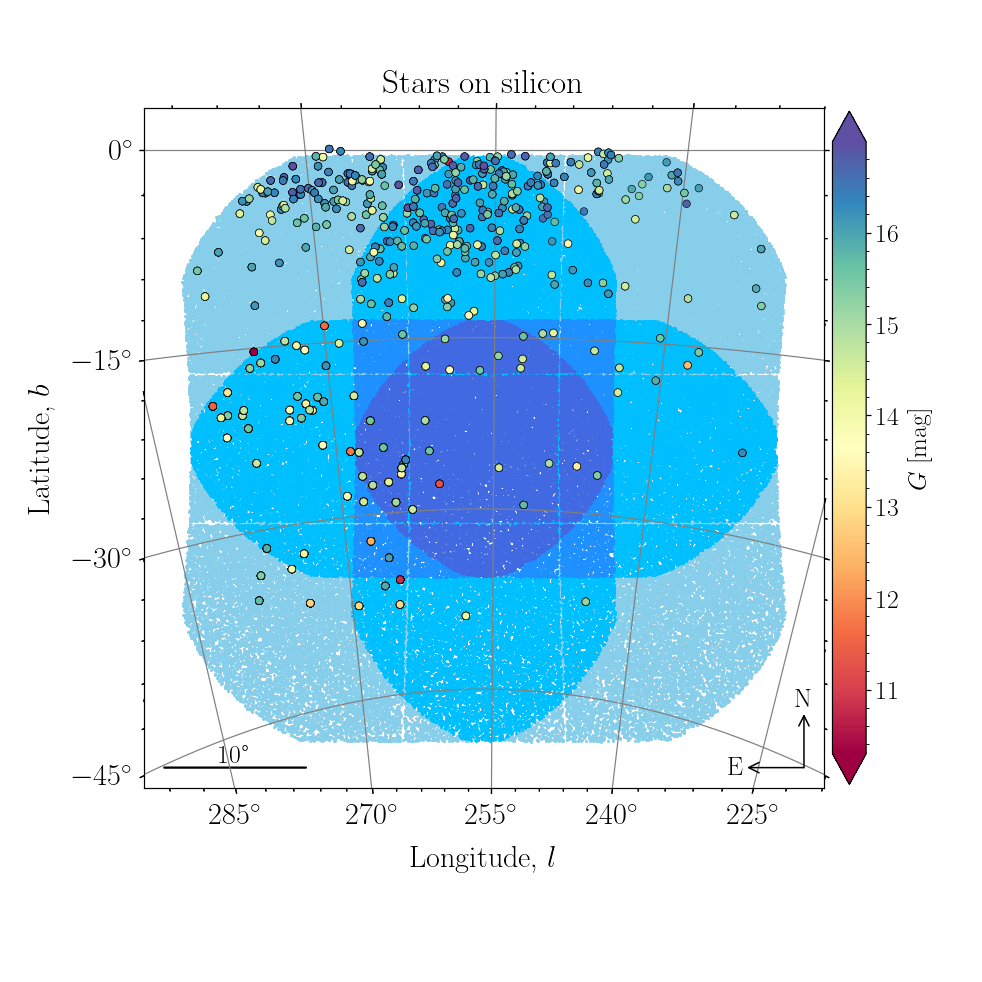

In [27]:
# Inspect the star not detected on silicon
dx = dt0.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag,
    clabel=r'$G$ [mag]', s=100, lw=0.4,
    title='Stars on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_on_silicon.png', bbox_inches='tight', dpi=200)

In [24]:
# Inspect stars not detected by PlatoSIm
dt1 = dt0[dt0.SPR.isna()]
# dt1.shape
dt1

,gaiaDR3,ra,dec,Gmag,BP_RP,ncon,SPR,NSR
53,Gaia DR3 5311647906816639360,139.199143,-52.959728,14.330250,0.868287,NaN,NaN,NaN
54,Gaia DR3 5311647906816639360,139.199143,-52.959728,14.330250,0.868287,NaN,NaN,NaN
55,Gaia DR3 5311647906816639360,139.199143,-52.959728,14.330250,0.868287,NaN,NaN,NaN
56,Gaia DR3 5311647906816639360,139.199143,-52.959728,14.330250,0.868287,NaN,NaN,NaN
506,Gaia DR3 5310620344484451712,139.523843,-54.560824,16.229431,0.680589,NaN,NaN,NaN
507,Gaia DR3 5310620344484451712,139.523843,-54.560824,16.229431,0.680589,NaN,NaN,NaN
508,Gaia DR3 5310620344484451712,139.523843,-54.560824,16.229431,0.680589,NaN,NaN,NaN
509,Gaia DR3 5310620344484451712,139.523843,-54.560824,16.229431,0.680589,NaN,NaN,NaN
821,Gaia DR3 5516909479119604992,125.976712,-45.014341,16.965311,2.501466,NaN,NaN,NaN
822,Gaia DR3 5516909479119604992,125.976712,-45.014341,16.965311,2.501466,NaN,NaN,NaN


<IPython.core.display.Javascript object>


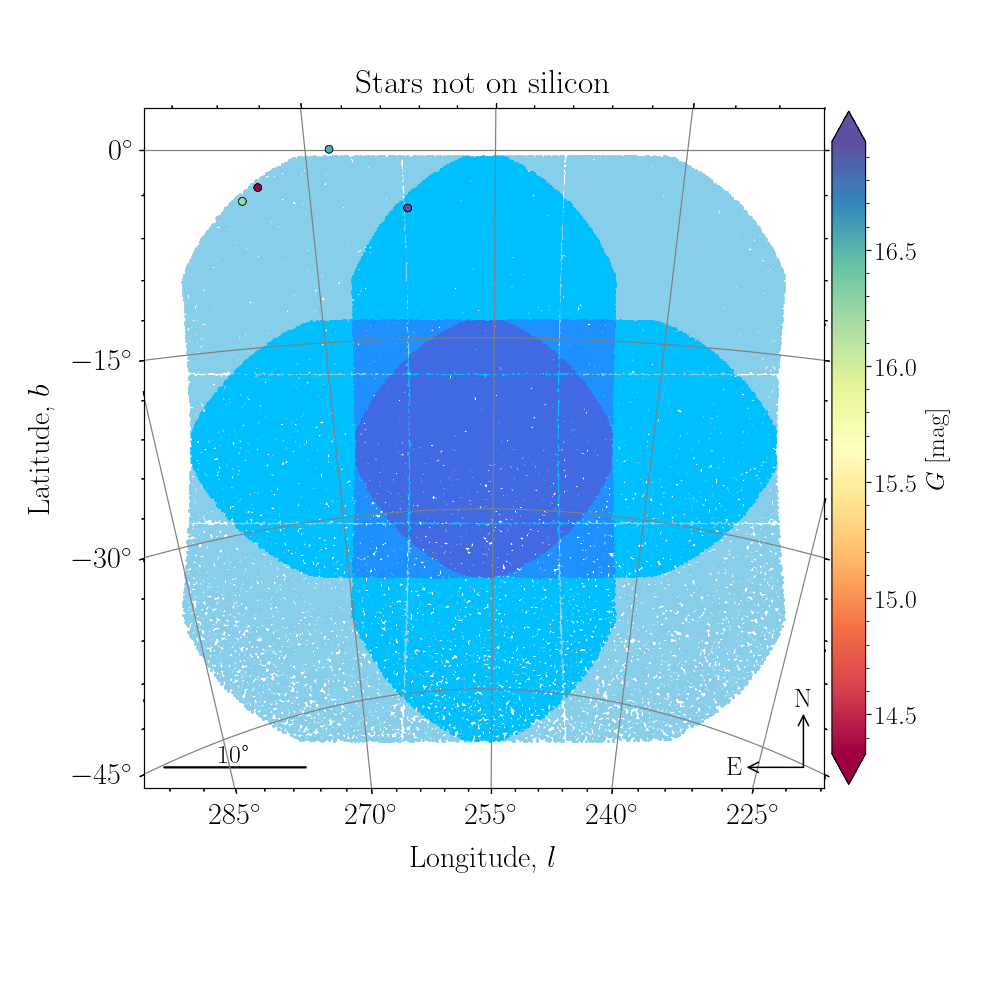

In [28]:
# Inspect the star not detected on silicon
dx = dt1.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Gmag,
    clabel=r'$G$ [mag]', s=100, lw=0.4,
    title='Stars not on silicon', figsize=(9,9),
)
fig.savefig(fdir / f'aitoff_targets_not_on_silicon.png', bbox_inches='tight', dpi=200)

In [26]:
# Save catalogue
dt0.to_csv(ddir / 'check_nik_ids1_on_silicon.csv', index=False)
dt1.to_csv(ddir / 'check_nik_ids1_not_on_silicon.csv', index=False)